In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv('/content/price_optimsation_dataset.csv')

In [85]:
df.shape

(676, 30)

## 676 rows and 30 columns

In [86]:
df.isna().sum().sum()

0

## No missing values

In [87]:
df[df.duplicated()].shape

(0, 30)

## No duplicated values

In [88]:
pd.set_option('display.max_columns', None)
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,weekday,weekend,holiday,month,year,s,volume,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,350,4.0,57,23,8,1,5,2017,10.267394,3800,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,350,4.0,61,22,8,1,6,2017,6.503115,3800,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,350,4.0,123,21,10,1,7,2017,12.071651,3800,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,350,4.0,90,23,8,1,8,2017,9.293873,3800,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,350,4.0,54,21,9,1,9,2017,5.555556,3800,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [89]:
set1=['qty','total_price', 'freight_price', 'unit_price', 'product_photos_qty', 'product_weight_g',
       'product_score']

set2=['product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume']

set3=['comp_1', 'ps1', 'fp1', 'lag_price', 'total_price']

set4=['comp_2', 'ps2', 'fp2', 'lag_price', 'total_price']

set5=['comp_3', 'ps3', 'fp3', 'lag_price', 'total_price']

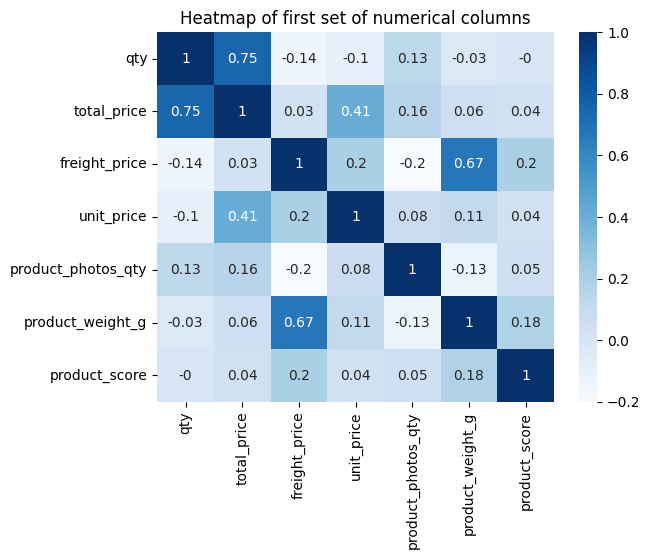

In [90]:
sns.heatmap(df[set1].corr().round(2),annot=True,cmap='Blues')
plt.title('Heatmap of first set of numerical columns')
plt.show()

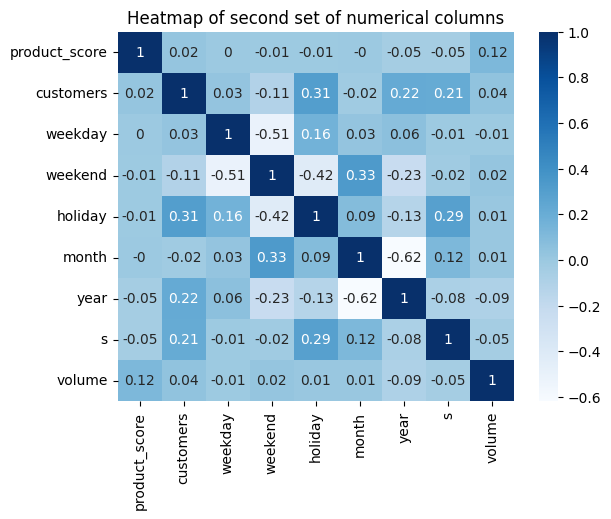

In [91]:
sns.heatmap(df[set2].corr().round(2),annot=True,cmap='Blues')
plt.title('Heatmap of second set of numerical columns')
plt.show()

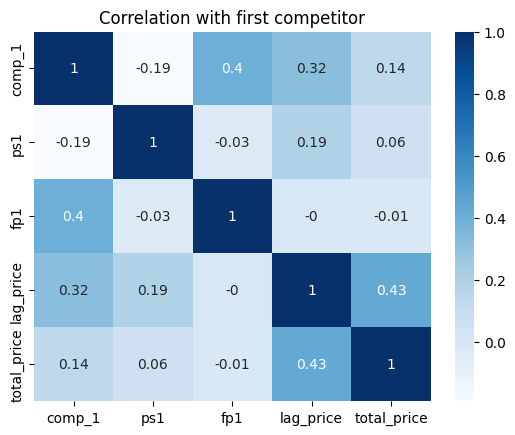

In [92]:
sns.heatmap(df[set3].corr().round(2),annot=True,cmap='Blues')
plt.title('Correlation with first competitor')
plt.show()

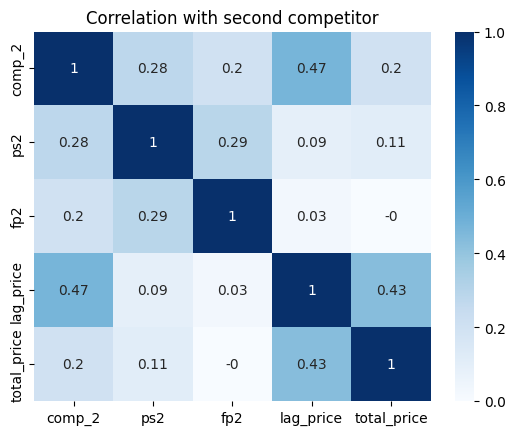

In [93]:
sns.heatmap(df[set4].corr().round(2),annot=True,cmap='Blues')
plt.title('Correlation with second competitor')
plt.show()

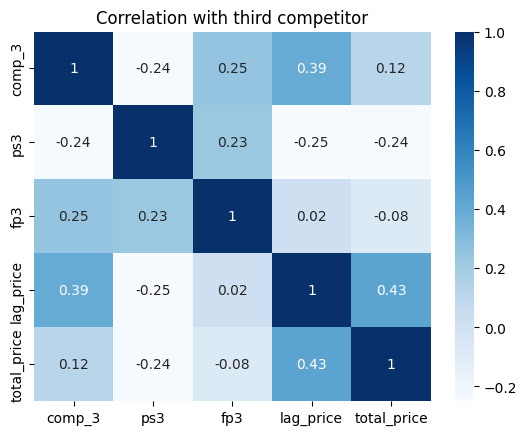

In [94]:
sns.heatmap(df[set5].corr().round(2),annot=True,cmap='Blues')
plt.title('Correlation with third competitor')
plt.show()

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [96]:
df['Revenue']=df.total_price-df.freight_price
df['comp']=(df.comp_1+df.comp_2+df.comp_3)/3
df['comp_ps']=(df.ps1+df.ps2+df.ps3)/3
df['comp_fp']=(df.fp1+df.fp2+df.fp3)/3
df=df.drop(columns=['month_year','qty','freight_price','unit_price','product_name_lenght','product_description_lenght','comp_1','comp_2','comp_3','ps1','ps2','ps3','fp1','fp2','fp3'])

In [97]:
df.columns

Index(['product_id', 'product_category_name', 'total_price',
       'product_photos_qty', 'product_weight_g', 'product_score', 'customers',
       'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume',
       'lag_price', 'Revenue', 'comp', 'comp_ps', 'comp_fp'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             676 non-null    object 
 1   product_category_name  676 non-null    object 
 2   total_price            676 non-null    float64
 3   product_photos_qty     676 non-null    int64  
 4   product_weight_g       676 non-null    int64  
 5   product_score          676 non-null    float64
 6   customers              676 non-null    int64  
 7   weekday                676 non-null    int64  
 8   weekend                676 non-null    int64  
 9   holiday                676 non-null    int64  
 10  month                  676 non-null    int64  
 11  year                   676 non-null    int64  
 12  s                      676 non-null    float64
 13  volume                 676 non-null    int64  
 14  lag_price              676 non-null    float64
 15  Revenu

In [99]:
df.head()

,product_id,product_category_name,total_price,product_photos_qty,product_weight_g,product_score,customers,weekday,weekend,holiday,month,year,s,volume,lag_price,Revenue,comp,comp_ps,comp_fp
0,bed1,bed_bath_table,45.95,2,350,4.0,57,23,8,1,5,2017,10.267394,3800,45.90,30.850000,116.950000,4.1,12.957299
1,bed1,bed_bath_table,137.85,2,350,4.0,61,22,8,1,6,2017,6.503115,3800,45.95,124.916667,114.950000,4.1,16.341516
2,bed1,bed_bath_table,275.70,2,350,4.0,123,21,10,1,7,2017,12.071651,3800,45.95,260.860000,113.616667,4.1,17.009922
3,bed1,bed_bath_table,183.80,2,350,4.0,90,23,8,1,8,2017,9.293873,3800,45.95,169.512500,111.786601,4.1,16.119047
4,bed1,bed_bath_table,91.90,2,350,4.0,54,21,9,1,9,2017,5.555556,3800,45.95,76.800000,99.749570,4.1,19.400403


In [100]:
set1=['product_photos_qty', 'product_weight_g','customers',
       'weekday', 'weekend', 'holiday', 'month', 'year', 's']

set2=['volume', 'lag_price', 'Revenue', 'comp', 'comp_ps', 'comp_fp', 'total_price', 'product_score']

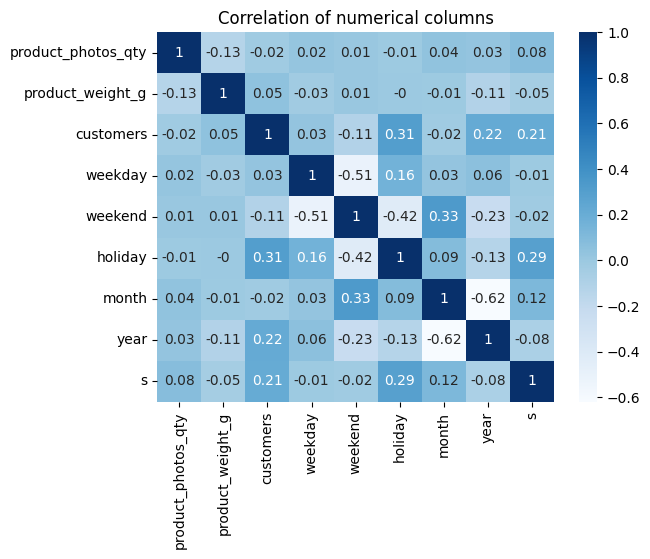

In [101]:
sns.heatmap(df[set1].corr().round(2),annot=True,cmap='Blues')
plt.title('Correlation of numerical columns')
plt.show()

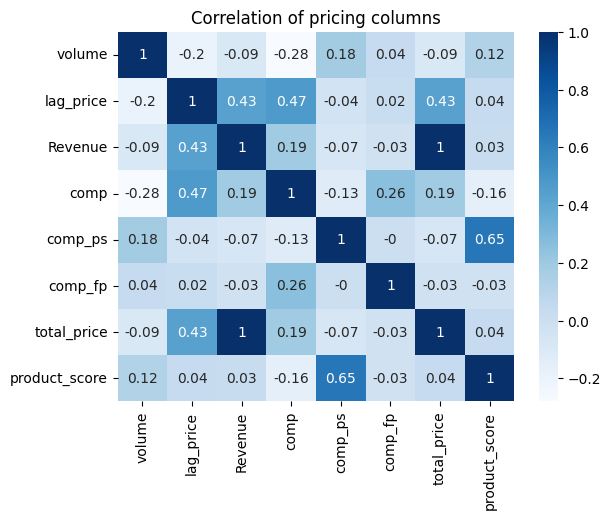

In [102]:
sns.heatmap(df[set2].corr().round(2),annot=True,cmap='Blues')
plt.title('Correlation of pricing columns')
plt.show()

## `lag_price` is mildly positively correlated `Revenue`, `Comp` and `total_price`.

## `product_score` is positively correlated with `comp_ps`.